<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day04-alignment-in-code.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 4 — Sequence Alignment in code

This notebook implements Needleman-Wunsch (global) and Smith-Waterman (local) alignment from scratch, reproduces the by-hand worked example from the Day 4 page, and visualizes the dynamic-programming matrix and traceback path.

The core algorithm functions below are adapted from Lukas Käll's open-access bioinformatics textbook, [*bibook*](https://github.com/statisticalbiotechnology/bibook) (`bibook/pairwise/nw_code.ipynb` and `sw_code.ipynb`), licensed [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). The visualization and the gap-penalty/scoring choices used to match this course's worked example are original to this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Adapted from bibook (Käll, CC BY 4.0): bibook/pairwise/nw_code.ipynb, sw_code.ipynb

def format_alignment(seqA, seqB, S, trace):
    """Traceback from the bottom-right corner to the top-left (global alignment)."""
    outA, outB = "", ""
    i, j = len(seqA), len(seqB)
    while i > 0 or j > 0:
        di, dj = trace[i, j]
        i += int(di)
        j += int(dj)
        outA = ("-" if di == 0 else seqA[i]) + outA
        outB = ("-" if dj == 0 else seqB[j]) + outB
    return outA, outB


def format_local_alignment(seqA, seqB, S, trace):
    """Traceback from the highest-scoring cell until a 0 is hit (local alignment)."""
    outA, outB = "", ""
    i, j = np.unravel_index(S.argmax(), S.shape)
    while min(trace[i, j]) < 0:
        di, dj = trace[i, j]
        i += int(di)
        j += int(dj)
        outA = ("-" if di == 0 else seqA[i]) + outA
        outB = ("-" if dj == 0 else seqB[j]) + outB
    return outA, outB

## Needleman-Wunsch (global alignment)

In [2]:
def global_align(seqA, seqB, match=1.0, mismatch=-1.0, gap=-1.0):
    def score(a, b):
        if a == '-' or b == '-':
            return gap
        return match if a == b else mismatch

    m, n = len(seqA) + 1, len(seqB) + 1
    S = np.zeros((m, n))
    trace = np.zeros((m, n, 2))
    for i in range(1, m):
        S[i, 0] = i * gap
        trace[i, 0, :] = (-1, 0)
    for j in range(1, n):
        S[0, j] = j * gap
        trace[0, j, :] = (0, -1)

    for i in range(1, m):
        for j in range(1, n):
            diag = S[i-1, j-1] + score(seqA[i-1], seqB[j-1])
            up = S[i-1, j] + gap
            left = S[i, j-1] + gap
            S[i, j] = max(diag, up, left)
            if diag >= max(up, left):
                trace[i, j, :] = (-1, -1)
            elif up >= left:
                trace[i, j, :] = (-1, 0)
            else:
                trace[i, j, :] = (0, -1)
    return S, trace

### Reproducing the Day 4 by-hand example

Same sequences, same scores (match +1, mismatch −1, gap −1) as the worked example on the Day 4 page — this should reproduce that exact matrix and alignment.

In [3]:
seqA, seqB = "GCAT", "GAC"
S, trace = global_align(seqA, seqB, match=1.0, mismatch=-1.0, gap=-1.0)

print("Score matrix V:")
print(S)
print()

outA, outB = format_alignment(seqA, seqB, S, trace)
print("Alignment:")
print(outA)
print(outB)
print("Score:", S[-1, -1])

Score matrix V:
[[ 0. -1. -2. -3.]
 [-1.  1.  0. -1.]
 [-2.  0.  0.  1.]
 [-3. -1.  1.  0.]
 [-4. -2.  0.  0.]]

Alignment:
GCAT
G-AC
Score: 0.0


### Visualizing the matrix and the traceback path

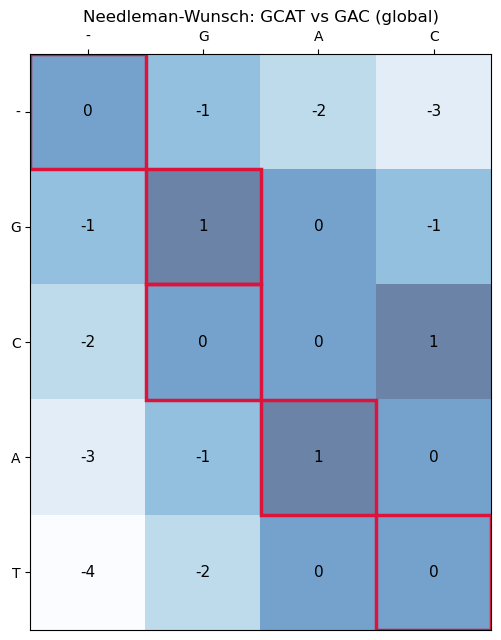

In [4]:
def plot_dp_matrix(seqA, seqB, S, trace, title, global_alignment=True):
    m, n = S.shape
    fig, ax = plt.subplots(figsize=(1.1*n + 1, 1.1*m + 1))
    ax.imshow(S, cmap="Blues", alpha=0.6)

    for i in range(m):
        for j in range(n):
            ax.text(j, i, f"{S[i,j]:.0f}", ha="center", va="center", fontsize=11)

    # highlight the traceback path
    if global_alignment:
        i, j = m - 1, n - 1
    else:
        i, j = np.unravel_index(S.argmax(), S.shape)
    path = [(i, j)]
    while (global_alignment and (i > 0 or j > 0)) or (not global_alignment and min(trace[i, j]) < 0):
        di, dj = trace[i, j]
        if di == 0 and dj == 0:
            break
        i, j = i + int(di), j + int(dj)
        path.append((i, j))
    for (pi, pj) in path:
        ax.add_patch(plt.Rectangle((pj-0.5, pi-0.5), 1, 1, fill=False, edgecolor="crimson", linewidth=2.5))

    ax.set_xticks(range(n)); ax.set_xticklabels(list("-" + seqB))
    ax.set_yticks(range(m)); ax.set_yticklabels(list("-" + seqA))
    ax.set_title(title)
    ax.xaxis.tick_top()
    plt.tight_layout()
    plt.show()

plot_dp_matrix(seqA, seqB, S, trace, "Needleman-Wunsch: GCAT vs GAC (global)")

## Smith-Waterman (local alignment)

In [5]:
def local_align(seqA, seqB, match=1.0, mismatch=-1.0, gap=-1.0):
    def score(a, b):
        if a == '-' or b == '-':
            return gap
        return match if a == b else mismatch

    m, n = len(seqA) + 1, len(seqB) + 1
    S = np.zeros((m, n))
    trace = np.zeros((m, n, 2))

    for i in range(1, m):
        for j in range(1, n):
            diag = S[i-1, j-1] + score(seqA[i-1], seqB[j-1])
            up = S[i-1, j] + gap
            left = S[i, j-1] + gap
            S[i, j] = max(diag, up, left, 0.0)
            if S[i, j] == 0:
                trace[i, j, :] = (0, 0)
            elif diag >= max(up, left):
                trace[i, j, :] = (-1, -1)
            elif up >= left:
                trace[i, j, :] = (-1, 0)
            else:
                trace[i, j, :] = (0, -1)
    return S, trace

### Global vs. local, side by side

Two sequences that share one strong matching region in the middle but are quite different elsewhere — global alignment is forced to account for the mismatched ends too, while local alignment finds just the strong match.

In [6]:
seqA, seqB = "TTGGCATTAGG", "AACGCATTACC"

S_g, trace_g = global_align(seqA, seqB)
outA_g, outB_g = format_alignment(seqA, seqB, S_g, trace_g)
print("Global (Needleman-Wunsch):")
print(outA_g)
print(outB_g)
print("Score:", S_g[-1, -1])
print()

S_l, trace_l = local_align(seqA, seqB)
outA_l, outB_l = format_local_alignment(seqA, seqB, S_l, trace_l)
print("Local (Smith-Waterman):")
print(outA_l)
print(outB_l)
print("Score:", S_l.max())

Global (Needleman-Wunsch):
TTGGCATTAGG
AACGCATTACC
Score: 1.0

Local (Smith-Waterman):
GCATTA
GCATTA
Score: 6.0


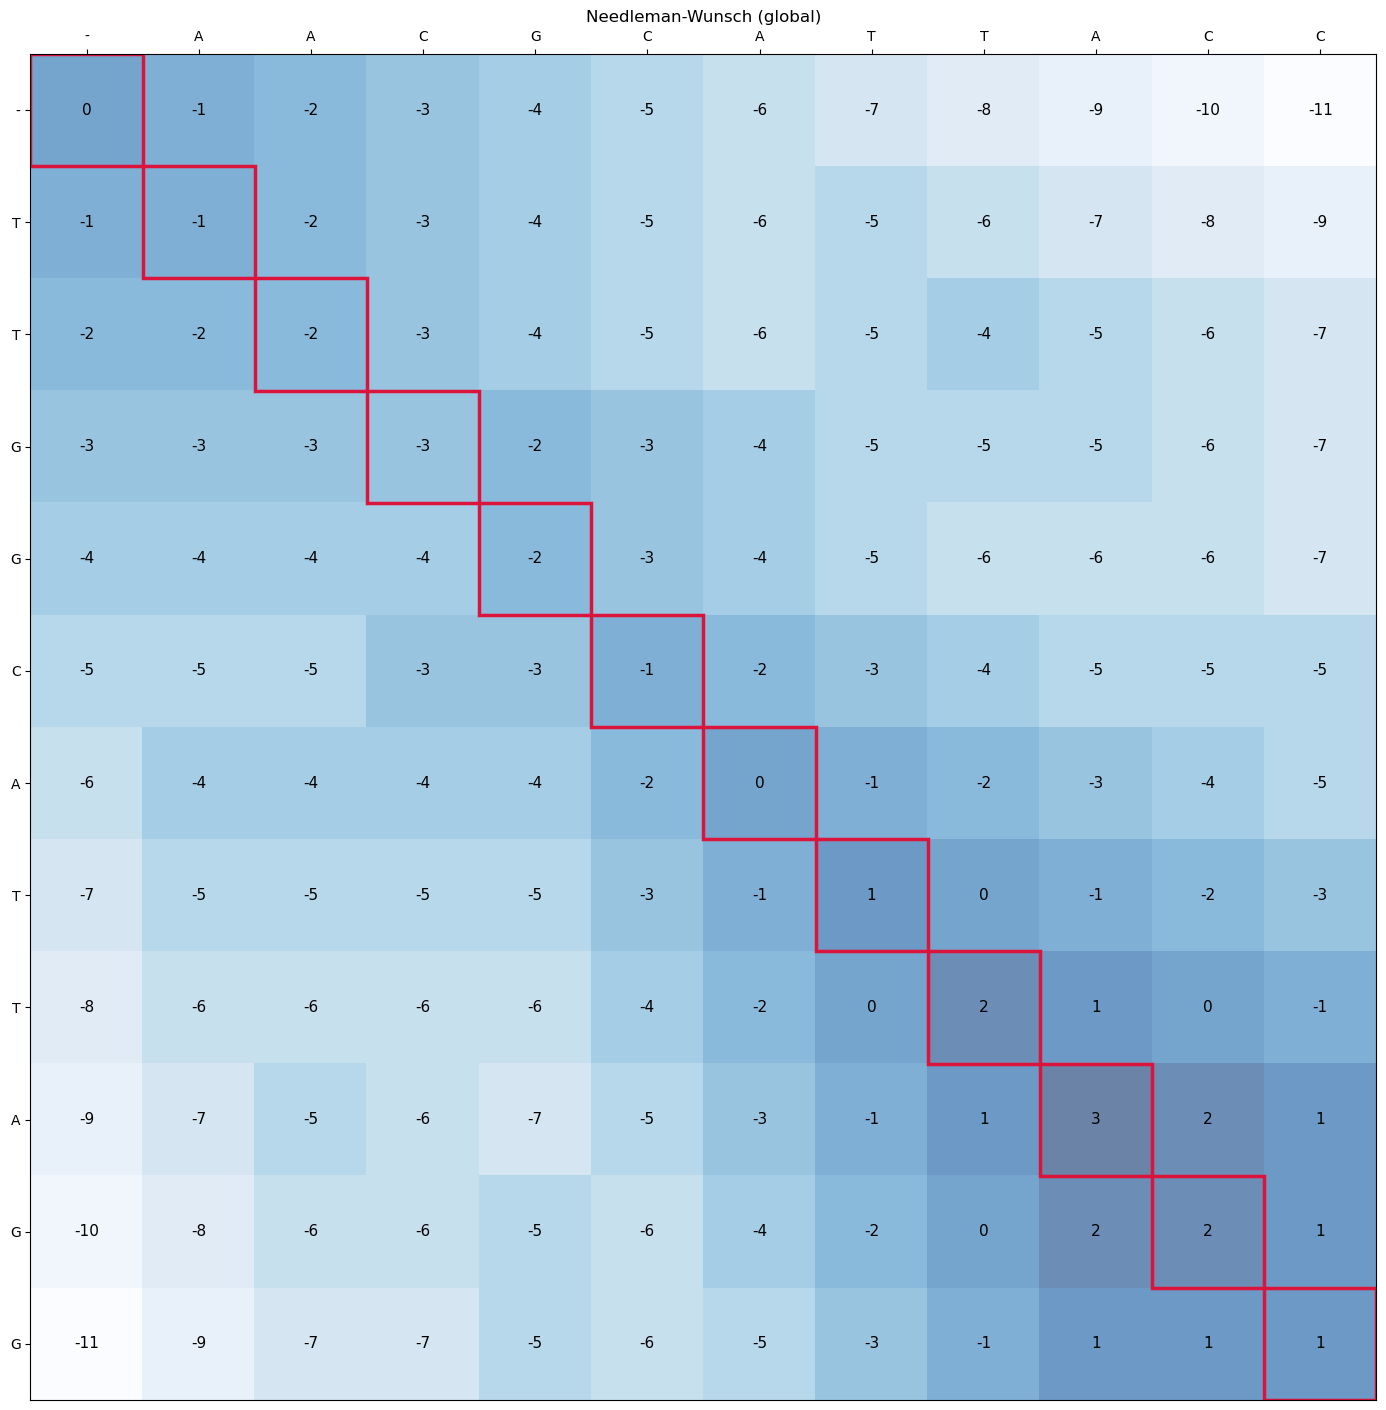

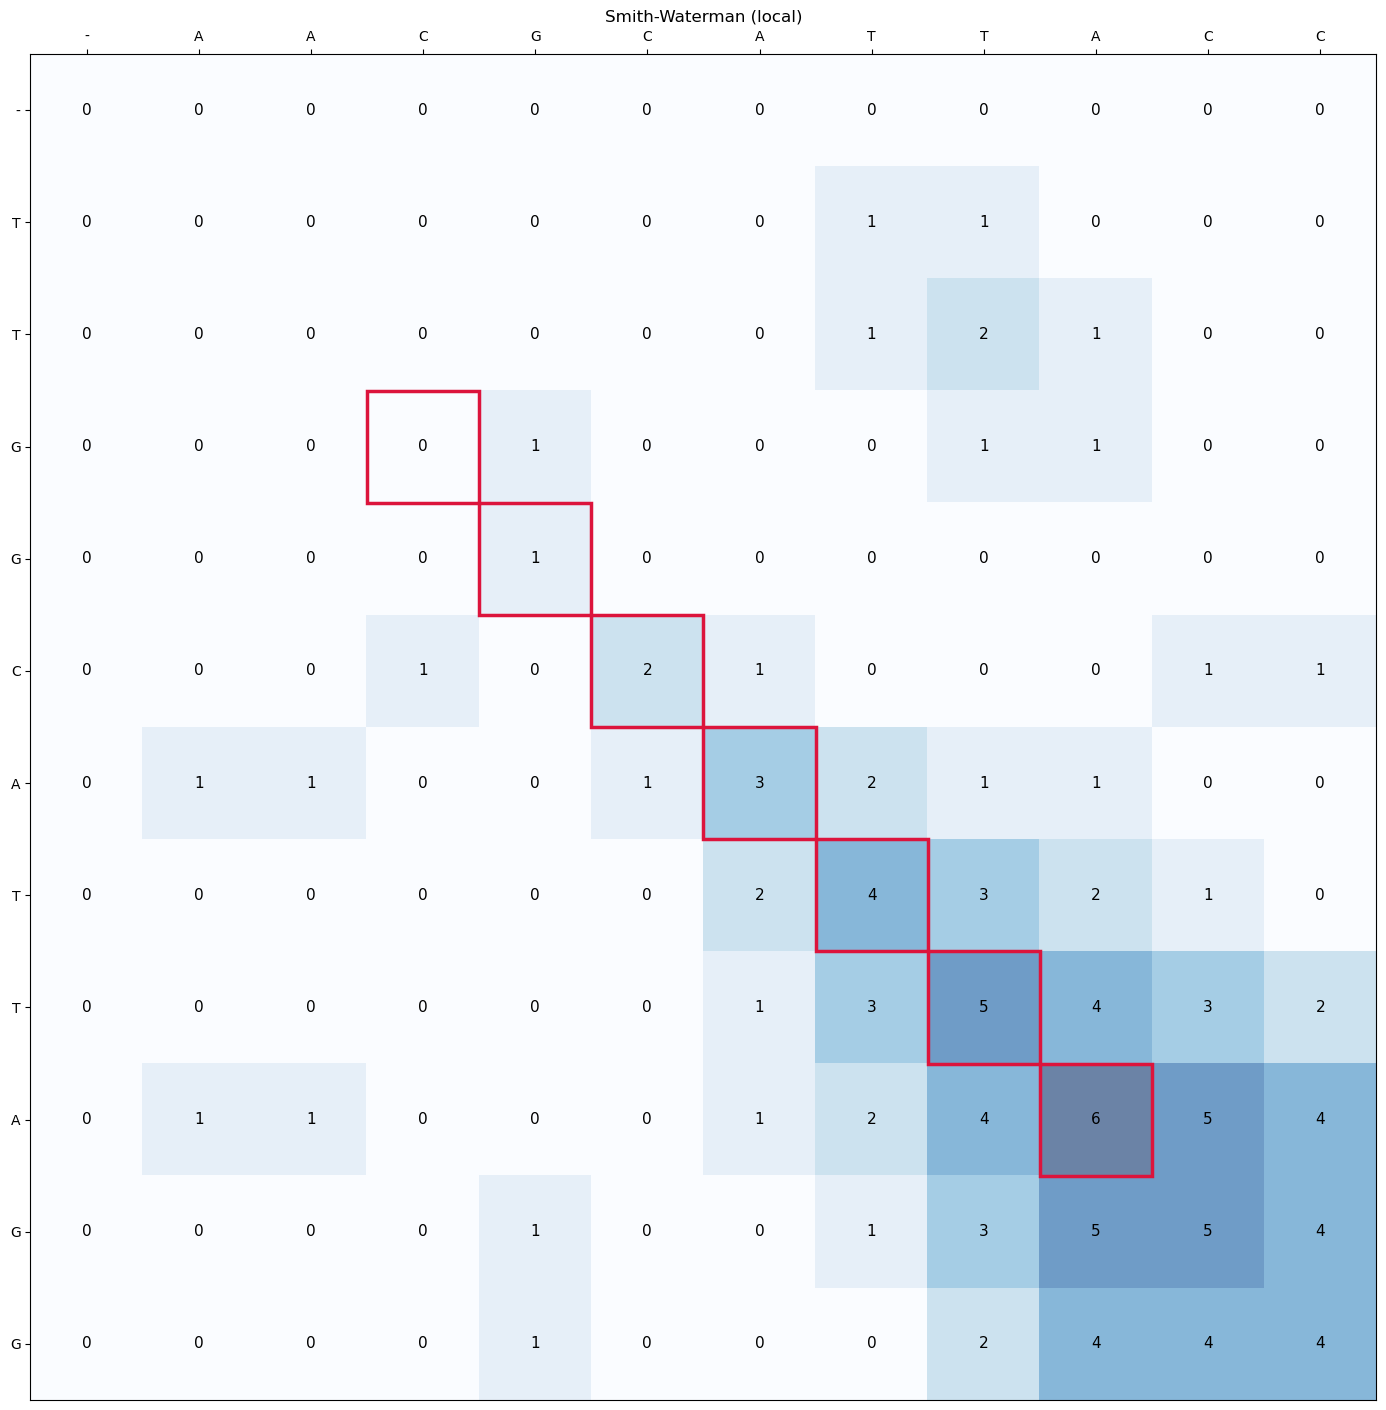

In [7]:
plot_dp_matrix(seqA, seqB, S_g, trace_g, "Needleman-Wunsch (global)", global_alignment=True)
plot_dp_matrix(seqA, seqB, S_l, trace_l, "Smith-Waterman (local)", global_alignment=False)

Notice how the local alignment's matrix has no negative numbers (any candidate score below zero is reset to zero, per Smith-Waterman's rule), and its traceback path is short — it starts at the single highest-scoring cell and stops as soon as it hits a zero, rather than being forced all the way to a corner. That's exactly the mechanical difference described on the Day 4 page, now visible directly in the matrix.

## Try it yourself

Change `seqA`/`seqB` above to your own sequences, or change the match/mismatch/gap scores, and re-run — in particular, try making the gap penalty very large or very small and see how that changes which alignment wins.